<a href="https://colab.research.google.com/github/valceven/AliacSearchAlgo/blob/master/FINALPRESENTKAPOYNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow
from roboflow import Roboflow

# Initialize Roboflow with your API key (replace this with your actual key)
rf = Roboflow(api_key="c32eqh0UKXsSvs8U2Iga")

# Access the project and version (in this case version 5)
project = rf.workspace("projects-mmpxg").project("chicken-yolo-tpynr")
version = project.version(5)  # Make sure to use the correct version number

# Download the dataset in multi-label classification format
dataset = version.download("multiclass")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to CHICKEN[YOLO]-5 in multiclass:: 100%|██████████| 4233/4233 [00:00<00:00, 5283.34it/s]


In [9]:
os.listdir('train')

['salmo', 'cocci', 'healthy', 'ncd']

In [4]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Path to your dataset
dataset_dir = 'CHICKEN[YOLO]-5/train'

# List all image files, excluding _classes.csv
files = [f for f in os.listdir(dataset_dir) if f != '_classes.csv']

# Label extraction (assuming the label is the first part of the filename)
labels = list(set([f.split('-')[0] for f in files]))

# Create directories for train, valid, test
os.makedirs('train', exist_ok=True)
os.makedirs('valid', exist_ok=True)
os.makedirs('test', exist_ok=True)

# Create subdirectories for each label in train, valid, and test
for label in labels:
    os.makedirs(f'train/{label}', exist_ok=True)
    os.makedirs(f'valid/{label}', exist_ok=True)
    os.makedirs(f'test/{label}', exist_ok=True)

# Split the dataset into train, valid, and test sets
train_files, test_files = train_test_split(files, test_size=0.3, random_state=42)
valid_files, test_files = train_test_split(test_files, test_size=0.5, random_state=42)

# Move the files into the respective directories
for file in train_files:
    label = file.split('-')[0]  # Extract the label from the filename
    shutil.move(os.path.join(dataset_dir, file), os.path.join('train', label, file))

for file in valid_files:
    label = file.split('-')[0]  # Extract the label from the filename
    shutil.move(os.path.join(dataset_dir, file), os.path.join('valid', label, file))

for file in test_files:
    label = file.split('-')[0]  # Extract the label from the filename
    shutil.move(os.path.join(dataset_dir, file), os.path.join('test', label, file))

print("Dataset has been split into train, valid, and test directories.")


ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [8]:
import os

# List of directories to clean
directories = ['train', 'valid', 'test']

# Remove '_classes.csv' from each directory if it's a file
for directory in directories:
    file_path = os.path.join(directory, '_classes.csv')
    if os.path.isdir(file_path):
        # If it's a directory, remove the directory
        shutil.rmtree(file_path)
        print(f'Removed directory _classes.csv from {directory} directory.')
    elif os.path.isfile(file_path):
        # If it's a file, remove the file
        os.remove(file_path)
        print(f'Removed _classes.csv file from {directory} directory.')
    else:
        print(f'_classes.csv not found in {directory} directory.')


Removed directory _classes.csv from train directory.
Removed directory _classes.csv from valid directory.
Removed directory _classes.csv from test directory.


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize images to [0, 1]
valid_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize images to [0, 1]
test_datagen = ImageDataGenerator(rescale=1.0/255.0)   # Normalize images to [0, 1]

# Load data from directories, with labels based on subfolders (each folder is a class)
train_dir = 'train'  # Path to your training data
valid_dir = 'valid'  # Path to your validation data
test_dir = 'test'    # Path to your test data

# Train data generator without rescaling
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize to match MobileNet input size
    batch_size=32,  # Adjust batch size as needed
    class_mode='categorical',  # Categorical labels (for multi-class classification)
    shuffle=True  # Shuffle data for training
)

# Validation data generator without rescaling
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # Don't shuffle validation data
)

# Test data generator without rescaling
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # Don't shuffle test data
)

# Print a sample to check if everything is working
for data_batch, labels_batch in train_generator:
    print(f"Data batch shape: {data_batch.shape}")
    print(f"Labels batch shape: {labels_batch.shape}")
    break  # Just show the first batch


Found 2960 images belonging to 4 classes.
Found 634 images belonging to 4 classes.
Found 635 images belonging to 4 classes.
Data batch shape: (32, 224, 224, 3)
Labels batch shape: (32, 4)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

IMG_SIZE = (224, 224, 3)
BATCH_SIZE = 32

def preprocess_image(img, label):
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, label

In [12]:
os.listdir('test')


['salmo', 'cocci', 'healthy', 'ncd']

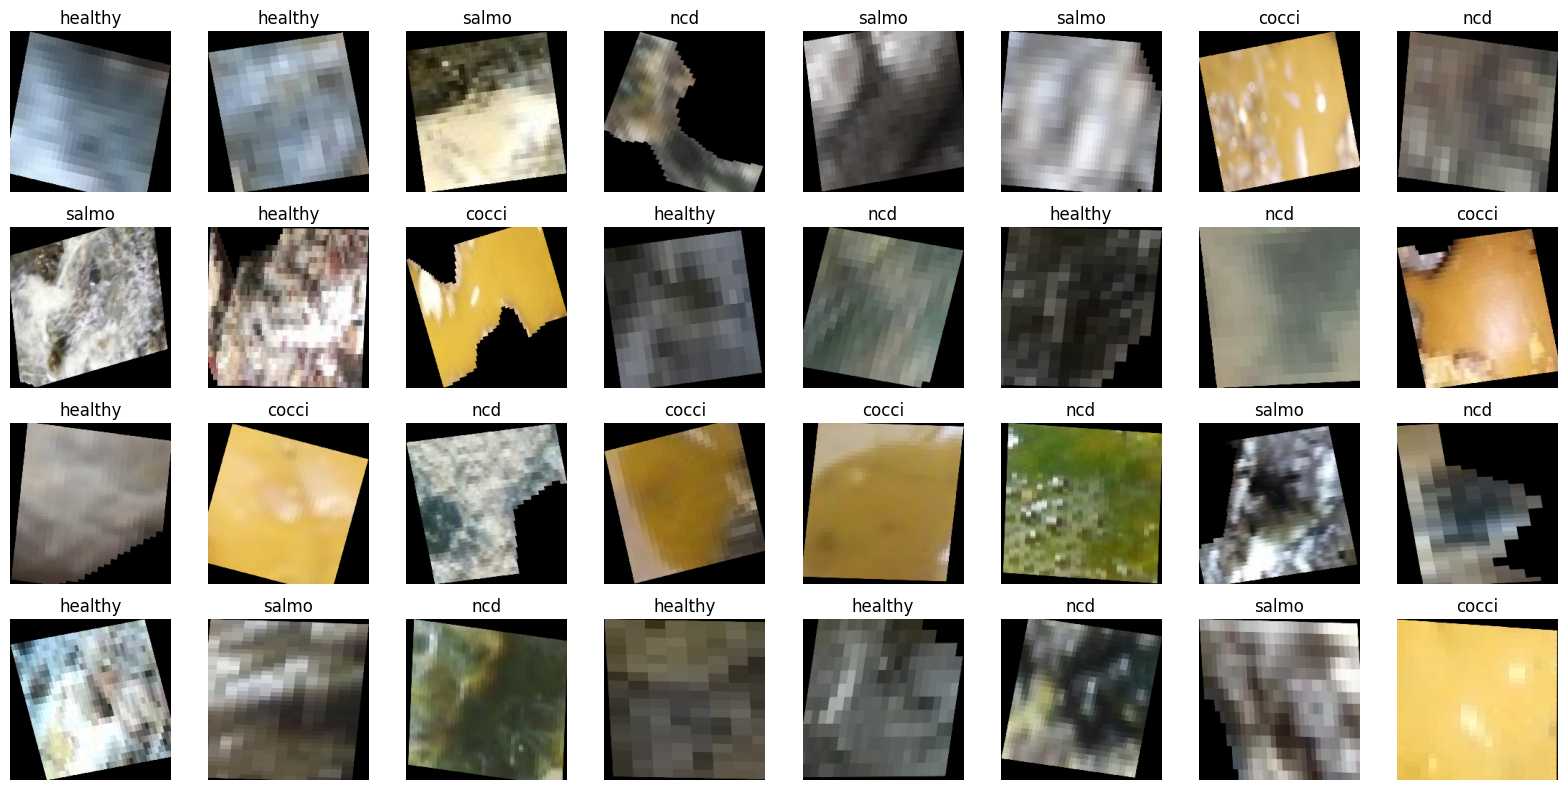

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of data from the train_generator
data_batch, labels_batch = next(train_generator)

# Get the class labels from the generator
class_labels = list(train_generator.class_indices.keys())

# Set up the figure for plotting
fig, axes = plt.subplots(4, 8, figsize=(16, 8))  # 4 rows and 8 columns of images
axes = axes.ravel()  # Flatten the axes array for easy iteration

# Plot 32 images (one per subplot)
for i in np.arange(32):
    ax = axes[i]
    image = data_batch[i]  # Get the i-th image
    image = np.clip(image * 255, 0, 255).astype('uint8')  # Rescale back to [0, 255] for display
    ax.imshow(image)  # Plot the image
    true_label = np.argmax(labels_batch[i])  # Get the true label index
    ax.set_title(class_labels[true_label])  # Set the title as the label
    ax.axis('off')  # Remove axis labels

plt.tight_layout()
plt.show()


In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load the MobileNetV2 model with ImageNet weights, excluding the top layers
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze the base model to prevent retraining the pre-trained weights
base_model.trainable = False

# Create the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')  # If your dataset has 5 classes

])

# Print the model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,432,420 (9.28 MB)

 Trainable params: 174,436 (681.39 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[EarlyStopping(patience=3)]
)

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 40s 307ms/step - accuracy: 0.3282 - loss: 1.4261 - val_accuracy: 0.4984 - val_loss: 1.1023
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.4545 - loss: 1.1600 - val_accuracy: 0.5915 - val_loss: 0.9651
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.5092 - loss: 1.0825 - val_accuracy: 0.5915 - val_loss: 0.9174
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.5562 - loss: 1.0069 - val_accuracy: 0.6167 - val_loss: 0.8732
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.5765 - loss: 0.9617 - val_accuracy: 0.6199 - val_loss: 0.8432
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.6189 - loss: 0.8960 - val_accuracy: 0.6246 - val_loss: 0.8382
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.6178 - loss: 0.9270 - val_accuracy: 0.6356 - val_loss: 0.8393
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.6394 - loss: 0.8568 - val_accu

In [18]:
base_model.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_generator,
          validation_data=valid_generator,
          epochs=50,
          callbacks=[EarlyStopping(patience=5)]
          )

Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 94s 474ms/step - accuracy: 0.5104 - loss: 1.2952 - val_accuracy: 0.5820 - val_loss: 1.0328
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.6707 - loss: 0.7745 - val_accuracy: 0.5631 - val_loss: 1.0927
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.7607 - loss: 0.6357 - val_accuracy: 0.4953 - val_loss: 1.1944
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.7937 - loss: 0.5758 - val_accuracy: 0.5457 - val_loss: 1.1228
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.8274 - loss: 0.4614 - val_accuracy: 0.6215 - val_loss: 0.8806
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.8588 - loss: 0.4075 - val_accuracy: 0.5741 - val_loss: 1.0873
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.8845 - loss: 0.3327 - val_accuracy: 0.6498 - val_loss: 0.9189
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.9041 - loss: 0.3034 - val_accu

In [19]:
model.evaluate(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - accuracy: 0.6767 - loss: 1.2122


[1.1228069067001343, 0.6724409461021423]

In [ ]:
model.predict(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step


array([[5.3838011e-15, 9.9999928e-01, 2.0021709e-08, 4.1387960e-07,
        3.6111132e-07],
       [2.5191316e-09, 9.9959868e-01, 2.4975407e-05, 1.9314366e-04,
        1.8317666e-04],
       [1.7506809e-12, 9.9997711e-01, 5.3981660e-07, 1.7052922e-05,
        5.1910906e-06],
       ...,
       [7.4984760e-06, 3.1169679e-03, 1.3544998e-01, 1.3350062e-01,
        7.2792494e-01],
       [3.1002828e-06, 1.0834283e-03, 1.6213787e-01, 9.2016190e-02,
        7.4475938e-01],
       [1.3344880e-04, 8.2887552e-04, 5.9886116e-01, 3.0972552e-01,
        9.0450943e-02]], dtype=float32)

In [20]:
model.save('ISMOBILE2.h5')
from google.colab import files
files.download('ISMOBILE2.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
from google.colab import files

uploadz = files.upload()

Saving nawnNIkeiru.jpg to nawnNIkeiru.jpg


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('ISMOBILE.h5')

In [44]:
os.listdir()

['.config',
 'train',
 'CHICKEN[YOLO]-5',
 'ISMOBILE2.h5',
 'valid',
 'Screenshot_28-4-2025_13914_www.bing.com.jpeg',
 'nawnNIkeiru.jpg',
 'test',
 'sample_data']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted class index: 2
Predicted class name: ncd


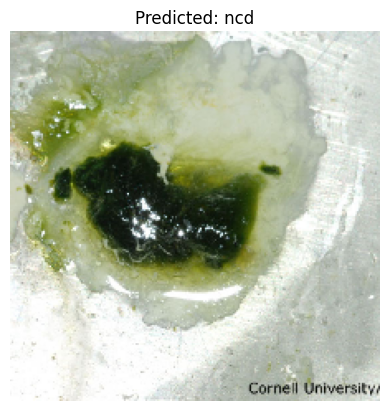

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load and preprocess a single image
img_path = 'nawnNIkeiru.jpg'  # Change this to the path of your image
img = image.load_img(img_path, target_size=(224, 224))  # Change the target size to your model's input size
img_array = image.img_to_array(img)  # Convert the image to an array
img_array = np.expand_dims(img_array, axis=0)  # Add an extra dimension to match model input shape
img_array = img_array / 255.0  # Normalize the image if necessary

# Get the predicted class for the single image
pred = model.predict(img_array)
y_pred = np.argmax(pred, axis=1)  # Convert from one-hot to class index

# Get class names from the test_generator
class_names = list(test_generator.class_indices.keys())

# Print the predicted class and its corresponding name
print(f"Predicted class index: {y_pred[0]}")
print(f"Predicted class name: {class_names[y_pred[0]]}")

# Display the image
plt.imshow(img)
plt.title(f"Predicted: {class_names[y_pred[0]]}")
plt.axis('off')
plt.show()


In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Get the predicted classes for the test set
preds = model.predict(test_generator, verbose=1)  # Predict all batches

# Convert predictions from one-hot to class indices
y_pred = np.argmax(preds, axis=1)

# Get the true labels from the test set
y_true = []
for _, label in test_generator:
    # For each batch, convert the labels from one-hot to indices
    y_true.extend(np.argmax(label, axis=1))  # Flatten the list and append

# Convert y_true list to a numpy array
y_true = np.array(y_true)

# Calculate accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Manual accuracy: {accuracy:.2%}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step


KeyboardInterrupt: 